In [2]:
!pip install pandas numpy matplotlib




[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
# Load data
file_path = r"C:\Users\AmnaSaied\Downloads\Pay prediction.csv"

# Load the data
df = pd.read_csv(file_path)

# Overview of the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1135 entries, 0 to 1134
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   APA Tenant                      1135 non-null   object 
 1   HasPay                          1135 non-null   int64  
 2   ActiveSubsidiaries              1135 non-null   int64  
 3   ActivatedModules                1135 non-null   int64  
 4   Sum of Employees                1110 non-null   float64
 5   ActiveUsers                     1135 non-null   int64  
 6   Industry                        1135 non-null   object 
 7   ERP                             1134 non-null   object 
 8   AP Automation                   1135 non-null   bool   
 9   Sum of APA License utilization  1090 non-null   float64
 10  Sum of Number of Locations      1042 non-null   float64
 11  Segment                         1135 non-null   object 
 12  Capture License Type            11

In [5]:
print(df.describe())

            HasPay  ActiveSubsidiaries  ActivatedModules  Sum of Employees  \
count  1135.000000         1135.000000       1135.000000       1110.000000   
mean      0.063436           11.874009          8.094273       3644.013514   
std       0.243853           36.386895          1.894230      21307.098760   
min       0.000000            2.000000          3.000000          3.000000   
25%       0.000000            2.000000          7.000000         78.250000   
50%       0.000000            5.000000          8.000000        310.500000   
75%       0.000000            9.500000          9.000000       1000.000000   
max       1.000000          660.000000         18.000000     396422.000000   

        ActiveUsers  Sum of APA License utilization  \
count   1135.000000                     1090.000000   
mean     387.212335                       66.436697   
std     1356.817592                       53.607269   
min        8.000000                        0.000000   
25%       55.000000   

In [6]:
# Check missing values
print(df.isnull().sum())

APA Tenant                         0
HasPay                             0
ActiveSubsidiaries                 0
ActivatedModules                   0
Sum of Employees                  25
ActiveUsers                        0
Industry                           0
ERP                                1
AP Automation                      0
Sum of APA License utilization    45
Sum of Number of Locations        93
Segment                            0
Capture License Type               0
Sub Industry                       0
Medius Territory                   0
AvgInvoicesPerMonth                0
AvgOverdueDays                     3
AvgCommentsPerDocument             0
AvgTimeToCompleteTask              0
AvgCompletedTasksPerWeek           0
AvgLinesPerInvoice                 0
DistinctLanguages                  0
OverdueInvoiceCount                0
Sum of ACV (USD)                   0
TotalArchivedInvoices              0
Account Description                0
dtype: int64


In [7]:
print(df[['Sum of Employees', 'Sum of APA License utilization', 'Sum of Number of Locations', 'AvgOverdueDays']].skew())


Sum of Employees                  12.147055
Sum of APA License utilization    19.353739
Sum of Number of Locations         8.349753
AvgOverdueDays                     2.214208
dtype: float64


In [8]:
!pip install seaborn matplotlib



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


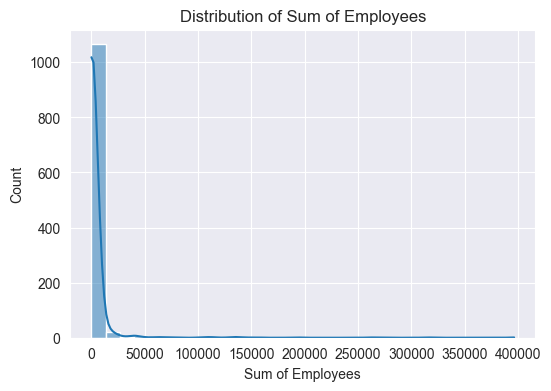

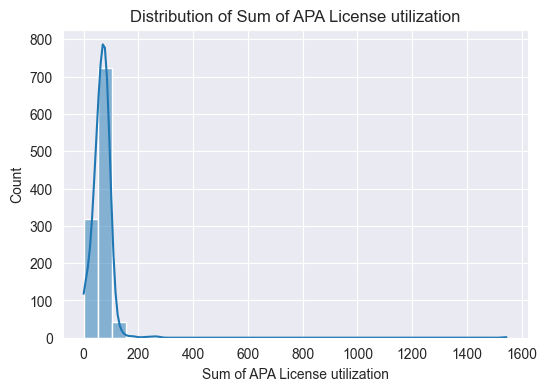

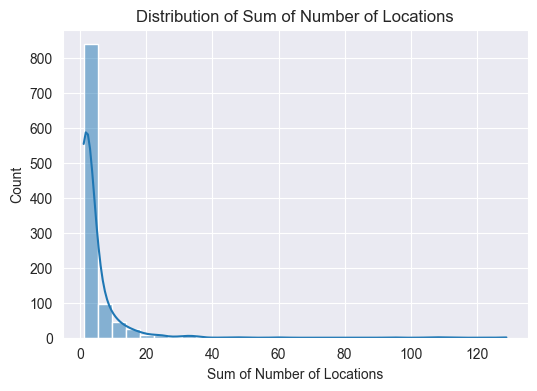

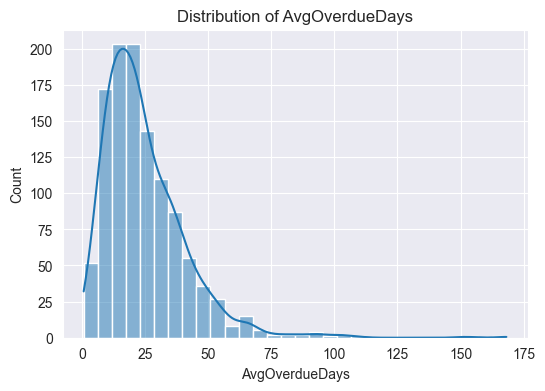

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columns to check
columns_to_check = ['Sum of Employees', 'Sum of APA License utilization', 'Sum of Number of Locations', 'AvgOverdueDays']

# Plot distributions
for col in columns_to_check:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()


In [10]:
# Check which values are returning NaN in the DataFrame
nan_values = df[df.isna().any(axis=1)]
print(nan_values)


        APA Tenant  HasPay  ActiveSubsidiaries  ActivatedModules  \
4              aam       0                   4                 7   
32           akers       1                   3                11   
42      alfamoving       0                   9                10   
70           arcus       0                  82                 9   
71           arcus       0                  82                 9   
...            ...     ...                 ...               ...   
1081       visolit       0                   8                 9   
1091  volvotruckdk       0                   5                 9   
1102     wegpolska       0                   6                 3   
1119     xlbyggkft       0                   2                 8   
1121         xvivo       1                   6                 8   

      Sum of Employees  ActiveUsers                      Industry  \
4                142.0          226  Manufacturing - Non-Durables   
32               348.0           78  Manufact

In [11]:
# Fill missing values for categorical columns with the mode
categorical_columns_with_nan = [
    'ERP'
]

for col in categorical_columns_with_nan:
    df[col] = df[col].fillna(df[col].mode()[0])  # Mode returns a series, so we take the first element


In [16]:
numerical_columns_with_nan = [ 'Sum of Employees', 'Sum of APA License utilization',
    'Sum of Number of Locations',
    'AvgOverdueDays'
]
# Fill missing values for numerical columns with the median

for col in numerical_columns_with_nan:
    df[col] = df[col].fillna(df[col].median())


In [17]:
df

,APA Tenant,HasPay,ActiveSubsidiaries,ActivatedModules,Sum of Employees,ActiveUsers,Industry,ERP,AP Automation,Sum of APA License utilization,...,AvgOverdueDays,AvgCommentsPerDocument,AvgTimeToCompleteTask,AvgCompletedTasksPerWeek,AvgLinesPerInvoice,DistinctLanguages,OverdueInvoiceCount,Sum of ACV (USD),TotalArchivedInvoices,Account Description
0,2xu,0,7,6,240.0,59,Retail,Apparel21,True,38.0,...,27.180712,1.710828,3.130565,787.203703,7.039703,2,1151,25680.10,5758,"Founded in Australia in 2005, 2XU is a technic..."
1,4cgroup,0,4,7,118.0,226,Professional Services,Visma Administration,True,45.0,...,16.271929,1.905237,1.357506,308.441860,1.375000,2,114,4111.88,1215,4C Strategies is a leading provider of organis...
2,aaacooper,0,3,7,6200.0,337,Logistics / Transportation,MS Dynamics AX,True,100.0,...,18.248596,1.916672,3.623532,24020.481480,1.584347,1,64132,144999.96,150053,"Founded in 1955, AAA Cooper Transportation, an..."
3,aaesbsp,0,15,7,151.0,445,Retail,Baan; Infor M3,True,45.0,...,21.380488,1.564303,1.088969,11403.462960,1.102656,5,12844,131655.44,53661,Portsystem AB is a company that operates in th...
4,aam,0,4,7,142.0,226,Manufacturing - Non-Durables,IFS,True,51.0,...,26.876218,1.623931,2.165624,6605.333333,2.511321,2,3692,57677.59,35750,Lamers High Tech Systems BV is a company that ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,zencargo,1,3,7,429.0,99,Computer Software,Oracle NetSuite,True,68.0,...,37.935288,1.645082,5.460574,9318.259259,1.000019,1,10879,42071.87,54474,Zencargo is a digital-first freight forwarder ...
1131,zijerveld,0,10,8,490.0,143,Manufacturing - Non-Durables,Infor M3,True,62.0,...,11.295820,1.892397,1.794567,7322.925925,2.469835,3,11054,74754.84,43634,Zijerveld serves both national and internation...
1132,zimmermannwear,0,18,6,264.0,349,Apparel,Apparel21,True,118.0,...,32.189268,1.536315,1.807181,6377.259259,1.000589,2,18096,19995.43,35210,"Founded in 1991, Zimmermann is a luxury Austra..."
1133,zollnergroup,0,4,8,53.0,123,Manufacturing - Non-Durables,Visma Business,True,84.0,...,29.605302,2.178440,2.297921,3644.925925,3.271557,3,1999,2712.53,20976,"Vlkommen till Nordic Souvenir, Nordens största..."


In [18]:
df.to_csv('cleaned_data.csv', index=False)
